# Modern Optimized Boosting: XGBoost and LightGBM

This notebook explores two state-of-the-art tree-boosting systems widely used in machine learning competitions:
1. **XGBoost (eXtreme Gradient Boosting)**: Implements gradient boosted decision trees designed for speed and performance. It features built-in L1/L2 regularization, handling of missing values, and parallelized tree construction.
2. **LightGBM (Light Gradient Boosting Machine)**: A fast, high-performance gradient boosting framework by Microsoft. It uses histogram-based algorithms to speed up training, and grows trees leaf-wise (best-first) rather than depth-wise.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style='whitegrid')
print('Libraries and models imported successfully!')

Libraries and models imported successfully!


In [2]:
df = pd.read_csv('../../Datasets/diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Data split ready.')

Data split ready.


In [3]:
# Train XGBoost Classifier
start_time = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f'XGBoost trained in {xgb_time:.4f} seconds.')
print(f'XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')

XGBoost trained in 0.0432 seconds.
XGBoost Accuracy: 0.7597


In [4]:
# Train LightGBM Classifier
start_time = time.time()
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start_time

y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print(f'LightGBM trained in {lgb_time:.4f} seconds.')
print(f'LightGBM Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}')

LightGBM trained in 1.3716 seconds.
LightGBM Accuracy: 0.7532


In [5]:
comparison_data = {
    'Metric': ['Training Time (s)', 'Test Accuracy', 'Test ROC-AUC'],
    'XGBoost': [xgb_time, accuracy_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_pred_proba_xgb)],
    'LightGBM': [lgb_time, accuracy_score(y_test, y_pred_lgb), roc_auc_score(y_test, y_pred_proba_lgb)]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Metric,XGBoost,LightGBM
0,Training Time (s),0.043158,1.371558
1,Test Accuracy,0.759740,0.753247
2,Test ROC-AUC,0.834259,0.824630


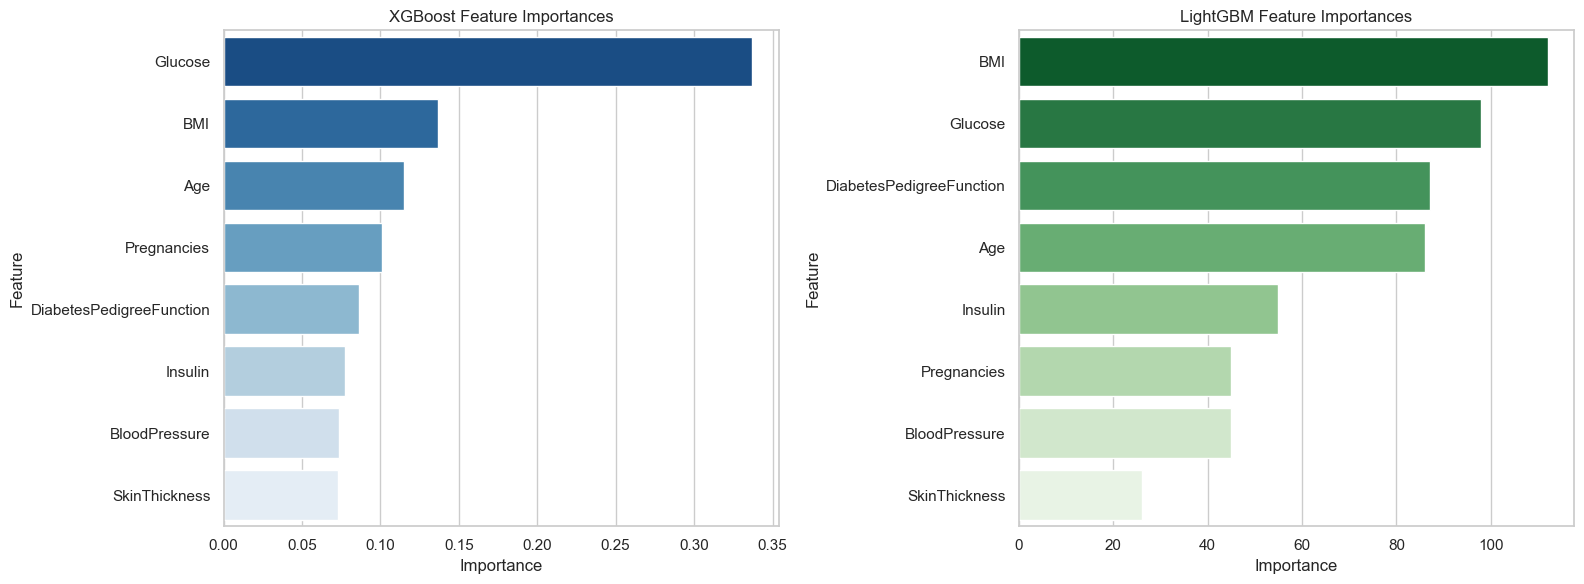

In [6]:
# Plot feature importances side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns, 'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
sns.barplot(ax=axes[0], x='Importance', y='Feature', data=xgb_importance, palette='Blues_r', hue='Feature', legend=False)
axes[0].set_title('XGBoost Feature Importances')

# LightGBM Feature Importance
lgb_importance = pd.DataFrame({
    'Feature': X.columns, 'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
sns.barplot(ax=axes[1], x='Importance', y='Feature', data=lgb_importance, palette='Greens_r', hue='Feature', legend=False)
axes[1].set_title('LightGBM Feature Importances')

plt.tight_layout()
plt.show()

### Key Takeaways:
1. Both XGBoost and LightGBM show highly competitive predictive performance.
2. LightGBM is typically significantly faster, especially on very large datasets, due to its histogram-based splitting method and leaf-wise tree growth.
3. Hyperparameter tuning (like learning rate, max depth, subsample, and regularization) is key to preventing overfitting on smaller datasets like Pima Diabetes.